In [2]:
from common import *
n = 2

# Build

In [3]:
a = QuantumRegister(2, name="A")
b = QuantumRegister(2, name="B")
s = QuantumRegister(3, name="S")

Using method 2 in [A Comprehensive Study of Quantum Arithmetic Circuits](https://arxiv.org/html/2406.03867v1#S5)

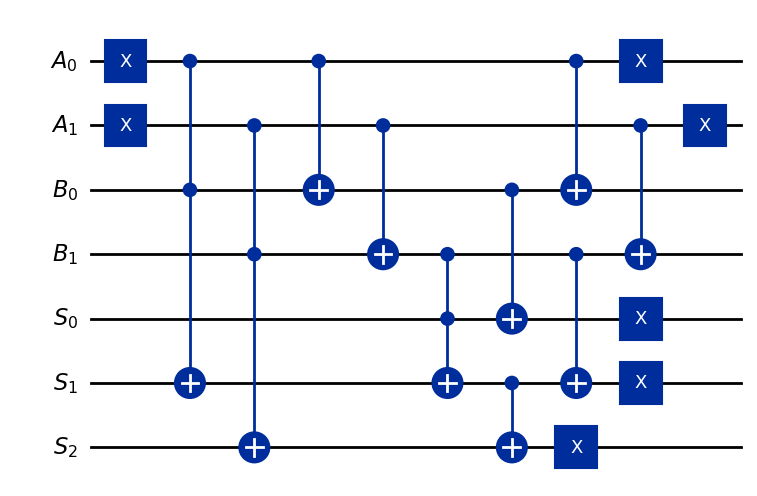

In [13]:
sub_qc = QuantumCircuit(a, b, s, name="Prefix Tree Subtractor")

# Flip A
for i in range(n):
    sub_qc.x(a[i])
# Adder below, copy from adder notebook
# Intial propagation and generation
for i in range(2):
    sub_qc.ccx(a[i], b[i], s[i+1]) # g, it's in the next index in s
    sub_qc.cx(a[i], b[i]) # p

# G
# G0 = g0
# G1 = g1 + p1 * g0
sub_qc.ccx(s[0], b[1], s[1])
# but XOR ≠ OR
# this is what is instructed in the Wang paper
# TODO use ancillas to calculate OR or verify which one is correct
# a + b = (a xor b) xor ab

# P is not computed because it is unnecessary

# c
# c0 = 0, c1 = G0 = g0, c2 = G1 = g0
sub_qc.cx(s[1], s[2])

# s
sub_qc.cx(b[0], s[0])
sub_qc.cx(b[1], s[1])
# last carry = last s

# uncompute p
for i in range(2):
    sub_qc.cx(a[i], b[i])
    
# Flip all
for i in range(n):
    sub_qc.x(a[i])
    sub_qc.x(s[i])
sub_qc.x(s[n])
    
sub_qc.draw("mpl")

# Test

In [14]:
print_metrics(sub_qc)

Size: 17
Toffoli count: 3
CZ count: 42
T count: 21
Depth: 8
Toffoli depth: 2
CZ depth: 26
T depth: 8
Width: 7
Algebraic connectivity: 1.0148377569644018


In [15]:
test_circuit(
    sub_qc,
    list(range(2**n)), a,
    list(range(2**n)), b,
    [a, b, s],
    lambda a, b: (a - b) % (2**(n+1)),
    (1, n+1)  # ignore last bit, its an overflow
)

Initial state: 0000000
Final state:   1000000
Initial state: 0000100
Final state:   0110100
Error: 0, 1: got 3, expected 7
Initial state: 0001000
Final state:   0101000
Error: 0, 2: got 2, expected 6
Initial state: 0001100
Final state:   1011100
Error: 0, 3: got 1, expected 5
Initial state: 0000001
Final state:   1010001
Initial state: 0000101
Final state:   1000101
Initial state: 0001001
Final state:   0111001
Error: 1, 2: got 3, expected 7
Initial state: 0001101
Final state:   0101101
Error: 1, 3: got 2, expected 6
Initial state: 0000010
Final state:   1100010
Initial state: 0000110
Final state:   0010110
Initial state: 0001010
Final state:   1001010
Initial state: 0001110
Final state:   0111110
Error: 2, 3: got 3, expected 7
Initial state: 0000011
Final state:   1110011
Initial state: 0000111
Final state:   1100111
Initial state: 0001011
Final state:   1011011
Initial state: 0001111
Final state:   1001111
Total wrongs: 6
Total tests: 16
  0, 1: got 3, expected 7
  0, 2: got 2, expec

# Run

00 - 00 = 000

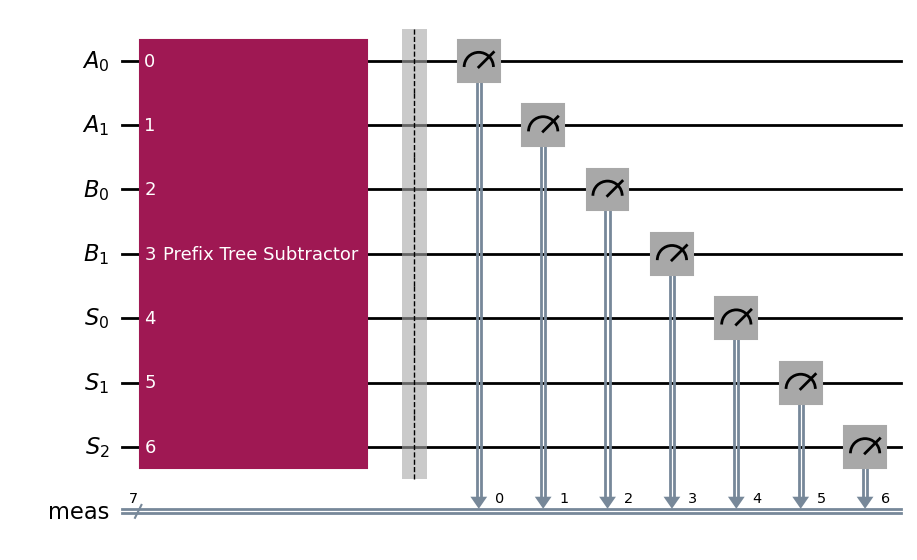

In [16]:
test_0 = QuantumCircuit(a, b, s)
test_0.append(sub_qc, [*a, *b, *s])
test_0.measure_active()
test_0.draw("mpl")

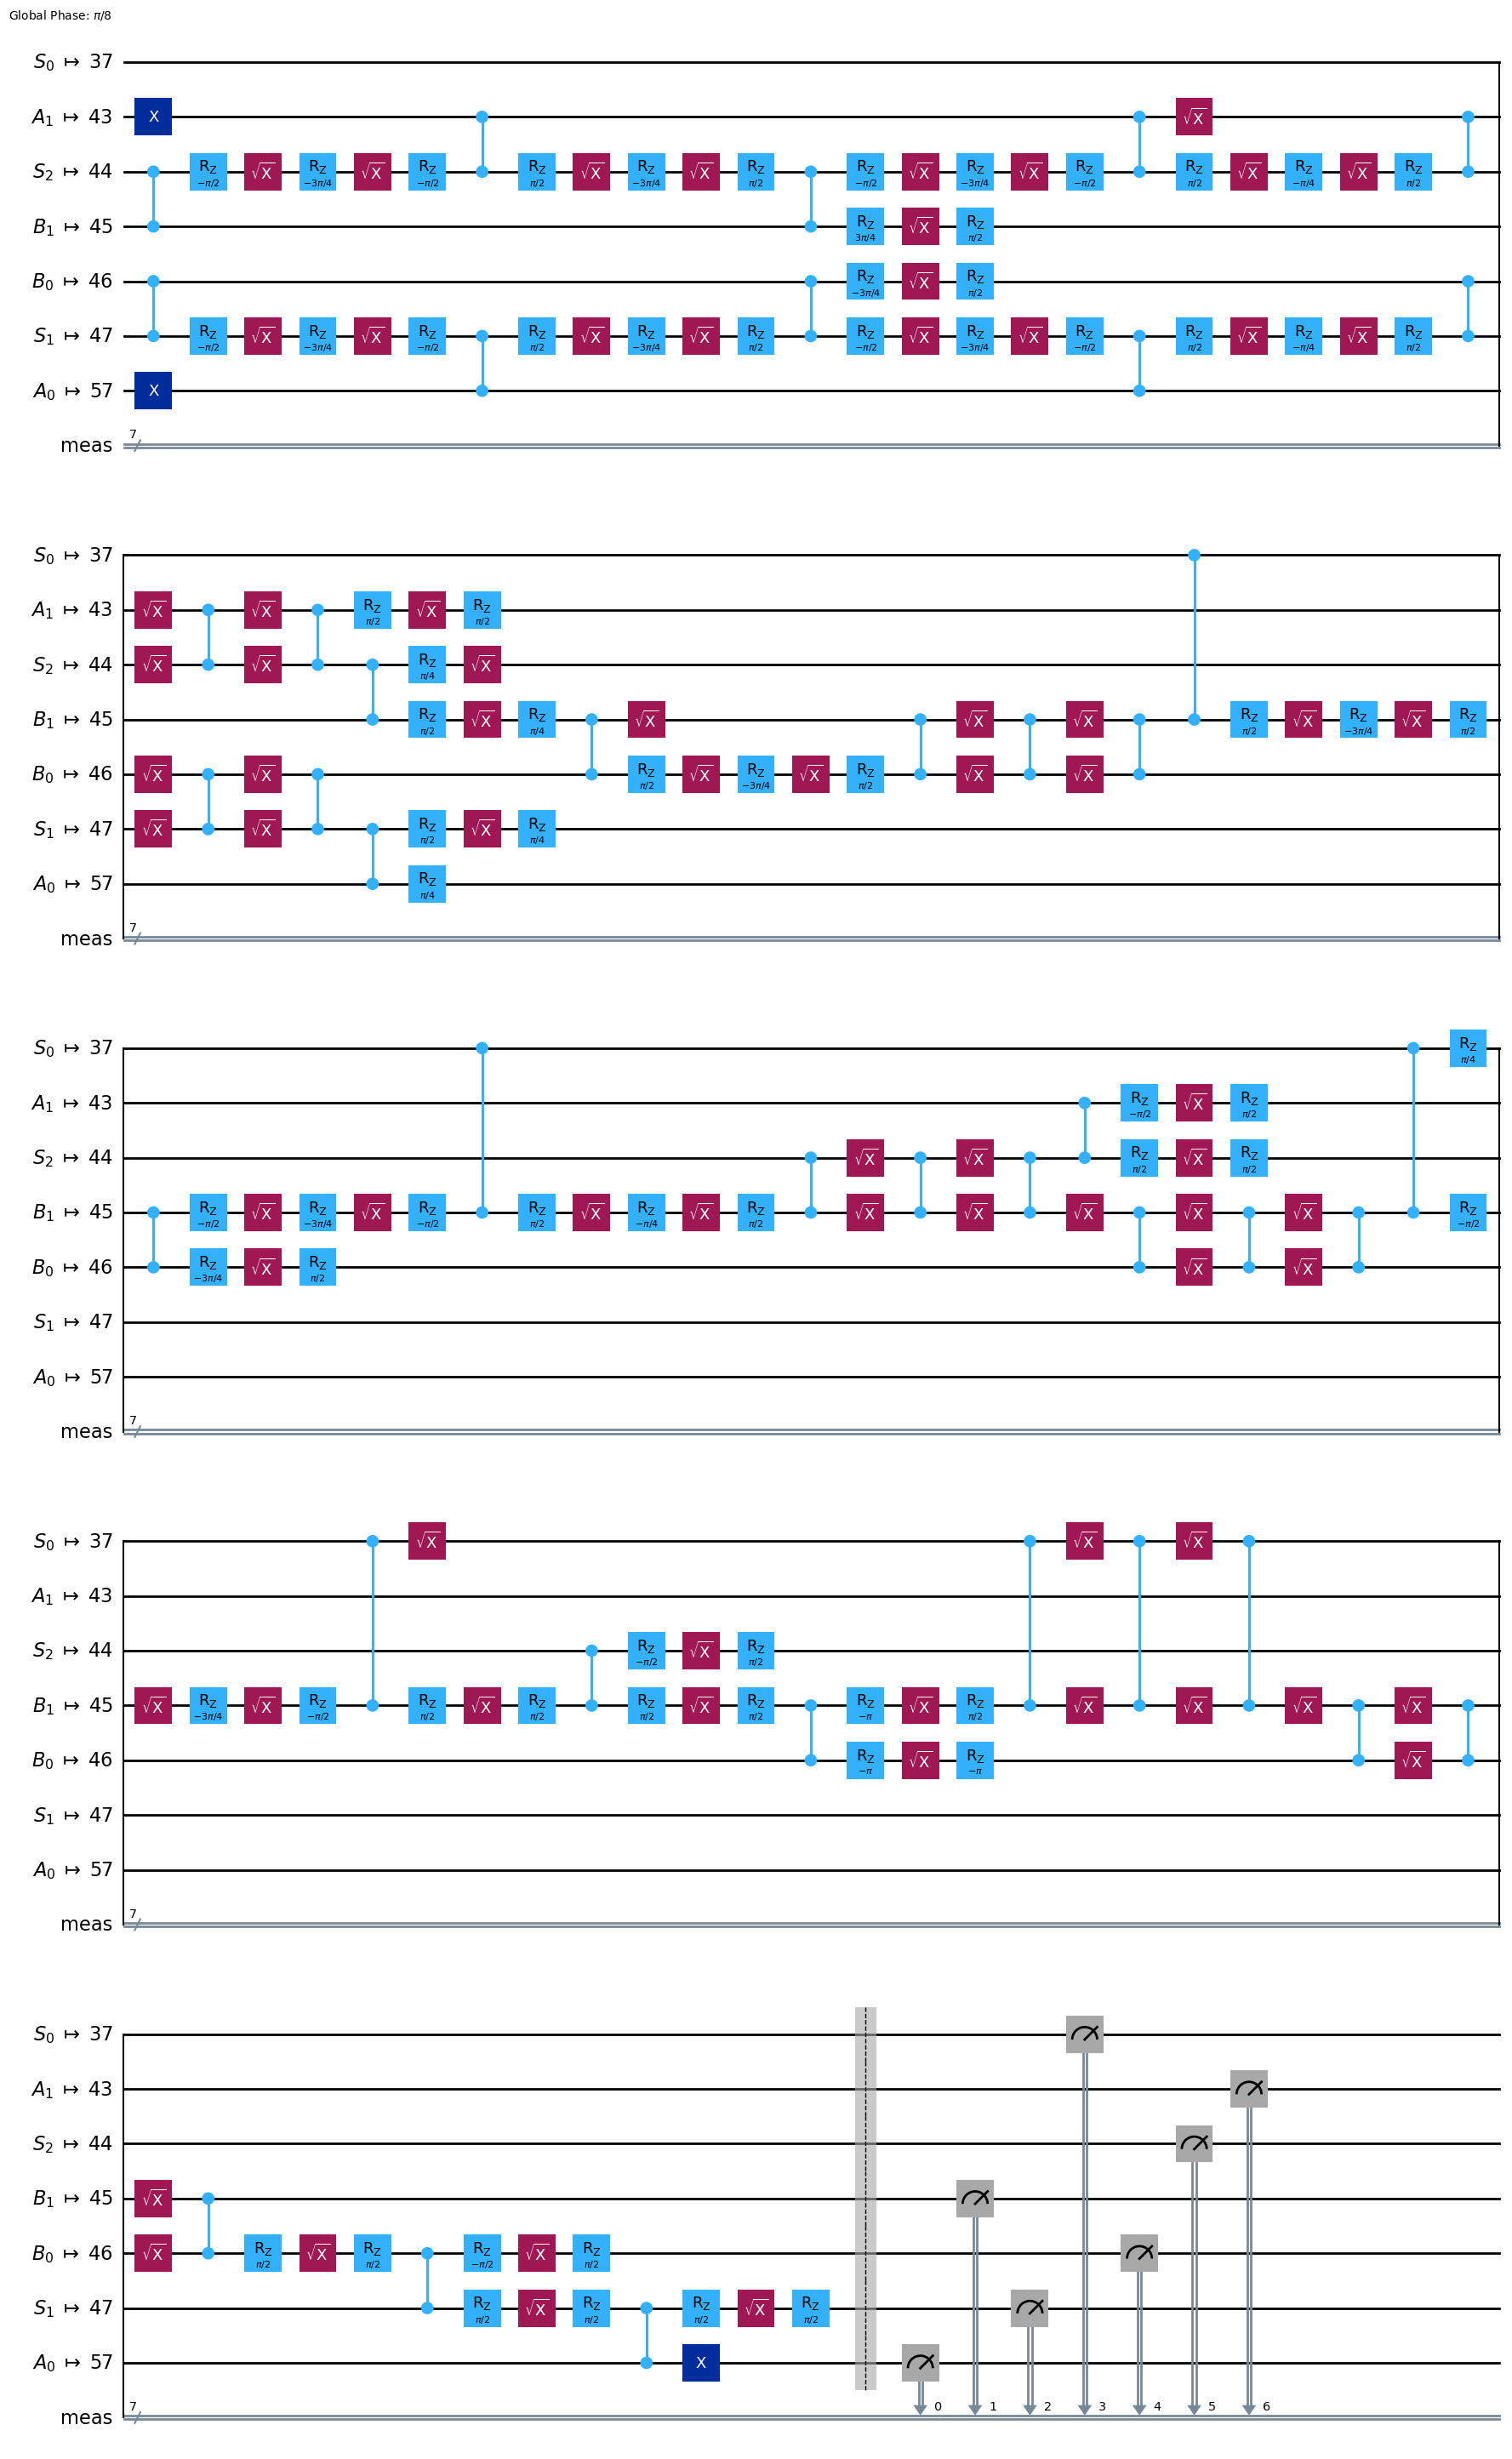

In [17]:
backend_sampler.options.default_shots = 2**11
isa_circ = pm.run(test_0)
isa_circ.draw("mpl")

In [18]:
job = backend_sampler.run([isa_circ])
print(f"Job ID: {job.job_id()}")

Job ID: d9ahrd66hjac73feemm0


In [19]:
inspect_results(job, "1000000")

Top 10 results:
{'1000000': 1622, '0000000': 49, '1010001': 39, '1101000': 32, '1100010': 32, '1001010': 23, '1010000': 18, '0110000': 16, '1001000': 13, '0100010': 13}
Number of keys: 68
Number of shots: 2048
Expected result 1000000: 1622
Probability: 0.7920


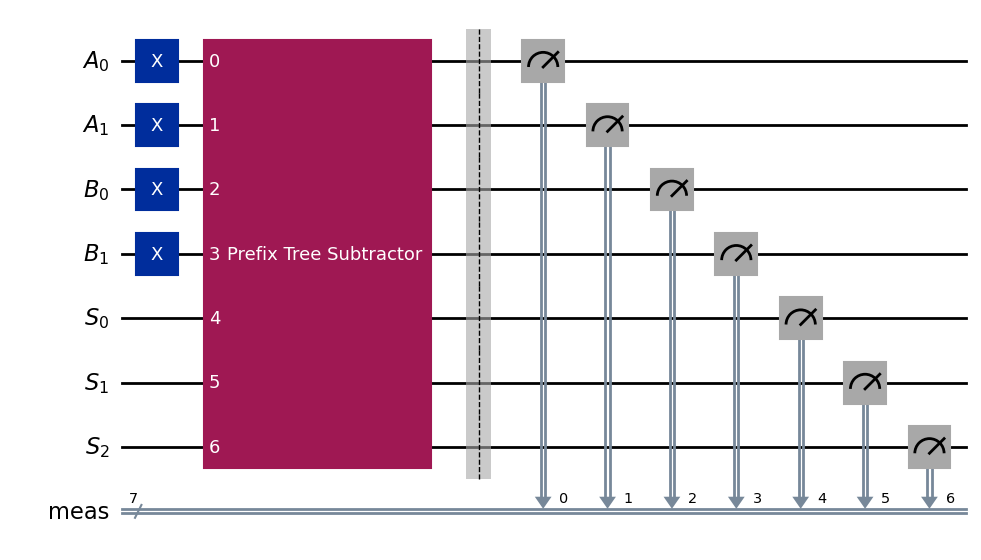

In [20]:
test_1 = QuantumCircuit(a, b, s)
for i in range(2):
    test_1.x(a[i])
    test_1.x(b[i])
test_1.append(sub_qc, [*a, *b, *s])
test_1.measure_active()
test_1.draw("mpl")

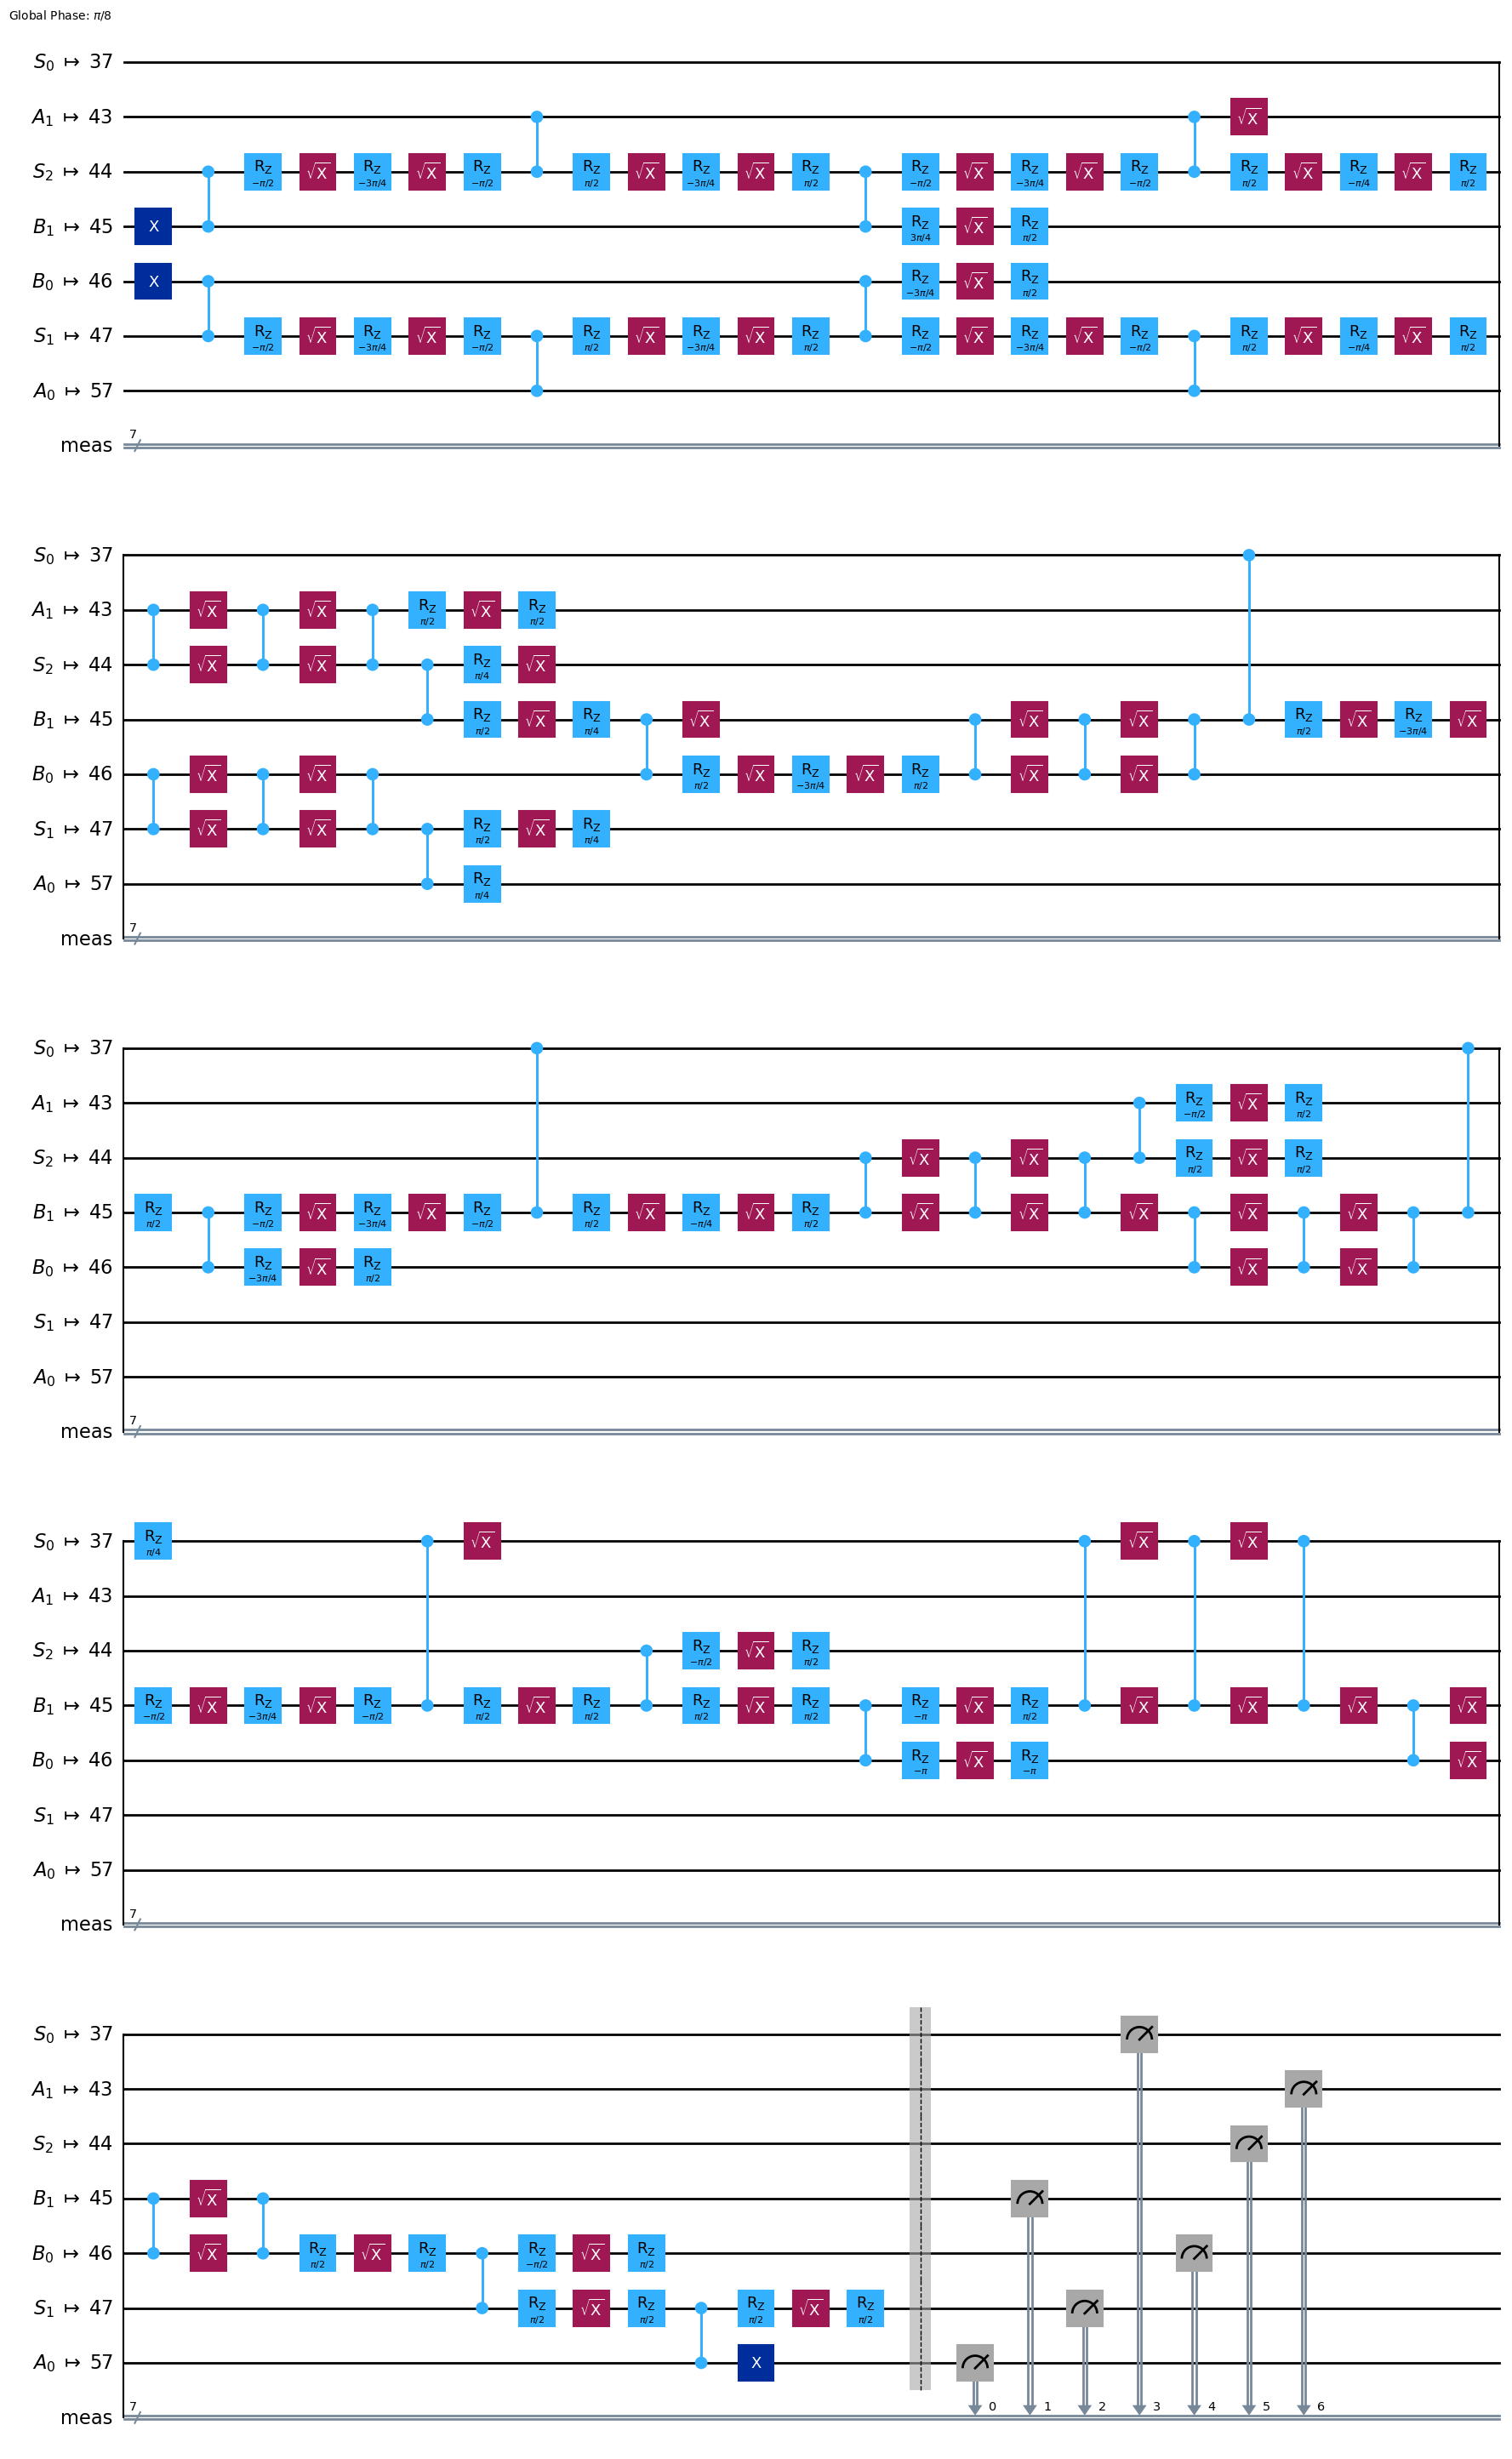

In [21]:
isa_circ = pm.run(test_1)
isa_circ.draw("mpl")

In [22]:
job = backend_sampler.run([isa_circ])
print(f"Job ID: {job.job_id()}")

Job ID: d9aht4e6hjac73feepm0


In [23]:
inspect_results(job, "1001111")

Top 10 results:
{'1001111': 1624, '0001111': 50, '1011011': 46, '1100111': 44, '1001011': 34, '1000111': 26, '1001110': 16, '1001101': 15, '0101101': 12, '1101101': 12}
Number of keys: 58
Number of shots: 2048
Expected result 1001111: 1624
Probability: 0.7930
